<a href="https://colab.research.google.com/github/Mehttap/DeepLearning/blob/main/Lung_Cancer_Prediction_Using_Naive_Bayes_and_Random_Forest1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For ignoring warning
import warnings
warnings.filterwarnings('ignore')



In [19]:
df=pd.read_csv('/content/survey lung cancer.csv')
df

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
304,F,56,1,1,1,2,2,2,1,1,2,2,2,2,1,YES
305,M,70,2,1,1,1,1,2,2,2,2,2,2,1,2,YES
306,M,58,2,1,1,1,1,1,2,2,2,2,1,1,2,YES
307,M,67,2,1,2,1,1,2,2,1,2,2,2,1,2,YES


Bu veri üzerinden önce Akciyer kanseri var mı ? yok mu ? bunun tespitini yapacağız. Bir clasification örneği.

Note: In this dataset, YES=2, NO=1

In [20]:
#Birbirinin aynı olan satır var mı? (Duplicates)
df.duplicated().sum()


np.int64(33)

In [21]:
#Tekrarları Sil

df=df.drop_duplicates()
df.shape

(276, 16)

In [22]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 276 entries, 0 to 283
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   GENDER                 276 non-null    object
 1   AGE                    276 non-null    int64 
 2   SMOKING                276 non-null    int64 
 3   YELLOW_FINGERS         276 non-null    int64 
 4   ANXIETY                276 non-null    int64 
 5   PEER_PRESSURE          276 non-null    int64 
 6   CHRONIC DISEASE        276 non-null    int64 
 7   FATIGUE                276 non-null    int64 
 8   ALLERGY                276 non-null    int64 
 9   WHEEZING               276 non-null    int64 
 10  ALCOHOL CONSUMING      276 non-null    int64 
 11  COUGHING               276 non-null    int64 
 12  SHORTNESS OF BREATH    276 non-null    int64 
 13  SWALLOWING DIFFICULTY  276 non-null    int64 
 14  CHEST PAIN             276 non-null    int64 
 15  LUNG_CANCER            276 n

In this dataset, Gender and Lung_Cancer attributes are in object data type;

Gender: M/F
Lung_Cancer: YES/NO bunu rakamla ifade edeceğiz.

Let's convert them to numerical values using LabelEncoder from sklearn.

LabelEncoder is a utility class to help normalize labels such that they contain only values between 0 and n_classses-1. It can also be used to transform non-numerical labels (as long as they are hashable and comparable) to numerical labels. Also let's make every other attributes as YES=1 and NO=0.

In [23]:
from sklearn import preprocessing
le= preprocessing.LabelEncoder()
df['GENDER']=le.fit_transform(df['GENDER'])
df['LUNG_CANCER']=le.fit_transform(df['LUNG_CANCER'])
df['SMOKING']=le.fit_transform(df['SMOKING'])
df['YELLOW_FINGERS']=le.fit_transform(df['YELLOW_FINGERS'])
df['ANXIETY']=le.fit_transform(df['ANXIETY'])
df['PEER_PRESSURE']=le.fit_transform(df['PEER_PRESSURE'])
df['CHRONIC DISEASE']=le.fit_transform(df['CHRONIC DISEASE'])
df['FATIGUE ']=le.fit_transform(df['FATIGUE '])
df['ALLERGY ']=le.fit_transform(df['ALLERGY '])
df['WHEEZING']=le.fit_transform(df['WHEEZING'])
df['ALCOHOL CONSUMING']=le.fit_transform(df['ALCOHOL CONSUMING'])
df['COUGHING']=le.fit_transform(df['COUGHING'])
df['SHORTNESS OF BREATH']=le.fit_transform(df['SHORTNESS OF BREATH'])
df['SWALLOWING DIFFICULTY']=le.fit_transform(df['SWALLOWING DIFFICULTY'])
df['CHEST PAIN']=le.fit_transform(df['CHEST PAIN'])
df['LUNG_CANCER']=le.fit_transform(df['LUNG_CANCER'])


In [24]:
#Let's check what's happened now
df

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,1,69,0,1,1,0,0,1,0,1,1,1,1,1,1,1
1,1,74,1,0,0,0,1,1,1,0,0,0,1,1,1,1
2,0,59,0,0,0,1,0,1,0,1,0,1,1,0,1,0
3,1,63,1,1,1,0,0,0,0,0,1,0,0,1,1,0
4,0,63,0,1,0,0,0,0,0,1,0,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279,0,59,0,1,1,1,0,0,1,1,0,1,0,1,0,1
280,0,59,1,0,0,0,1,1,1,0,0,0,1,0,0,0
281,1,55,1,0,0,0,0,1,1,0,0,0,1,0,1,0
282,1,46,0,1,1,0,0,0,0,0,0,0,0,1,1,0


Note: Male=1 and Female=0. yaptık
Ayrıca diğer değerleri ise YES=1, NO=0 olarak düzelttik.

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 276 entries, 0 to 283
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   GENDER                 276 non-null    int64
 1   AGE                    276 non-null    int64
 2   SMOKING                276 non-null    int64
 3   YELLOW_FINGERS         276 non-null    int64
 4   ANXIETY                276 non-null    int64
 5   PEER_PRESSURE          276 non-null    int64
 6   CHRONIC DISEASE        276 non-null    int64
 7   FATIGUE                276 non-null    int64
 8   ALLERGY                276 non-null    int64
 9   WHEEZING               276 non-null    int64
 10  ALCOHOL CONSUMING      276 non-null    int64
 11  COUGHING               276 non-null    int64
 12  SHORTNESS OF BREATH    276 non-null    int64
 13  SWALLOWING DIFFICULTY  276 non-null    int64
 14  CHEST PAIN             276 non-null    int64
 15  LUNG_CANCER            276 non-null    int64


Değerlerin hepsini integara çevirdiğimiz için artık modele sokabiliriz.

Şimdi elimizdeki veri dengeli mi değil mi buna bakacağız:

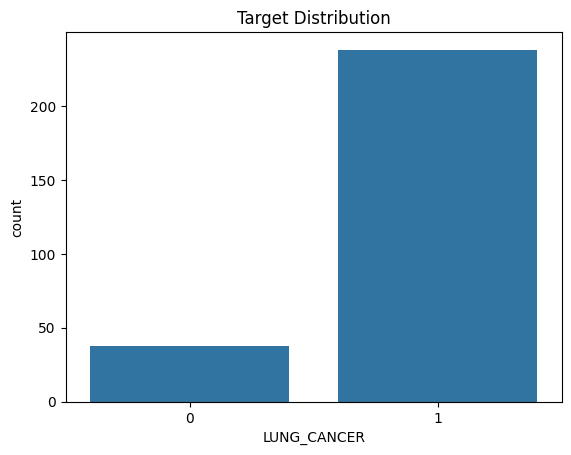

In [26]:
# Let's check the distributaion of Target variable

sns.countplot(x='LUNG_CANCER', data=df,)
plt.title('Target Distribution');

That is, Target Distribution is imbalanced. Çünkü 238 tane kanser örneği varken sadece 38 tane kanser olmayan örneği var. Bu yüzden biz sentetik veri üreterek bu verideki dengesizliği gidermeye çalışacağız.

In [27]:
df['LUNG_CANCER'].value_counts()

,count
LUNG_CANCER,
1,238
0,38


We will handle this imbalance before applying algorithm. Now let's do some Data Visualizations for the better understanding of how the independent features are related to the target variable..

In [28]:
# function for plotting (her bir kolon için hastalığın dağılımına bakma)

def plot(col, df=df):
  return df.groupby(col)['LUNG_CANCER'].value_counts(normalize=True).unstack().plot(kind='bar', figsize=(8,5))

<Axes: xlabel='GENDER'>

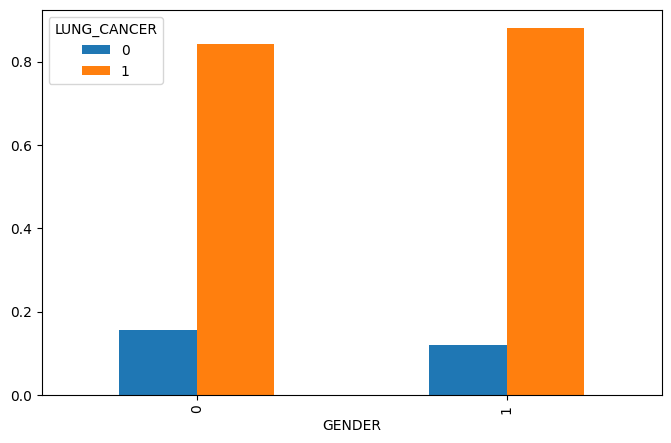

In [29]:
plot('GENDER')

<Axes: xlabel='AGE'>

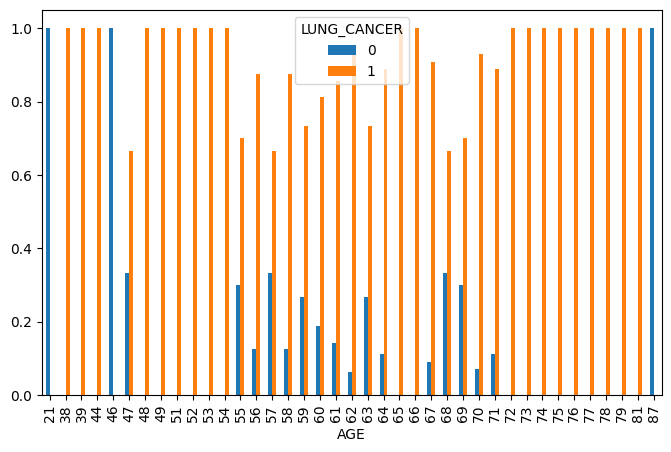

In [30]:
plot('AGE')

<Axes: xlabel='SMOKING'>

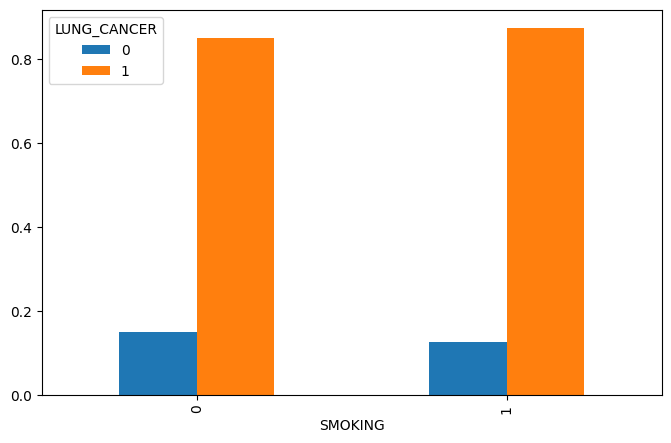

In [31]:
plot('SMOKING')

**Correlation**

In [33]:
#Finding Correlation
# Önce Korelasyonu Sayısal bir Metris olarak çizdiriyor

cn=df.corr()
cn

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
GENDER,1.000000,-0.013120,0.041131,-0.202506,-0.152032,-0.261427,-0.189925,-0.079020,0.150174,0.121047,0.434264,0.120228,-0.052893,-0.048959,0.361547,0.053666
AGE,-0.013120,1.000000,-0.073410,0.025773,0.050605,0.037848,-0.003431,0.021606,0.037139,0.052803,0.052049,0.168654,-0.009189,0.003199,-0.035806,0.106305
SMOKING,0.041131,-0.073410,1.000000,-0.020799,0.153389,-0.030364,-0.149415,-0.037803,-0.030179,-0.147081,-0.052771,-0.138553,0.051761,0.042152,0.106984,0.034878
YELLOW_FINGERS,-0.202506,0.025773,-0.020799,1.000000,0.558344,0.313067,0.015316,-0.099644,-0.147130,-0.058756,-0.273643,0.020803,-0.109959,0.333349,-0.099169,0.189192
ANXIETY,-0.152032,0.050605,0.153389,0.558344,1.000000,0.210278,-0.006938,-0.181474,-0.159451,-0.174009,-0.152228,-0.218843,-0.155678,0.478820,-0.123182,0.144322
PEER_PRESSURE,-0.261427,0.037848,-0.030364,0.313067,0.210278,1.000000,0.042893,0.094661,-0.066887,-0.037769,-0.132603,-0.068224,-0.214115,0.327764,-0.074655,0.195086
CHRONIC DISEASE,-0.189925,-0.003431,-0.149415,0.015316,-0.006938,0.042893,1.000000,-0.099411,0.134309,-0.040546,0.010144,-0.160813,-0.011760,0.068263,-0.048895,0.143692
FATIGUE,-0.079020,0.021606,-0.037803,-0.099644,-0.181474,0.094661,-0.099411,1.000000,-0.001841,0.152151,-0.181573,0.148538,0.407027,-0.115727,0.013757,0.160078
ALLERGY,0.150174,0.037139,-0.030179,-0.147130,-0.159451,-0.066887,0.134309,-0.001841,1.000000,0.166517,0.378125,0.206367,-0.018030,-0.037581,0.245440,0.333552
WHEEZING,0.121047,0.052803,-0.147081,-0.058756,-0.174009,-0.037769,-0.040546,0.152151,0.166517,1.000000,0.261061,0.353657,0.042289,0.108304,0.142846,0.249054


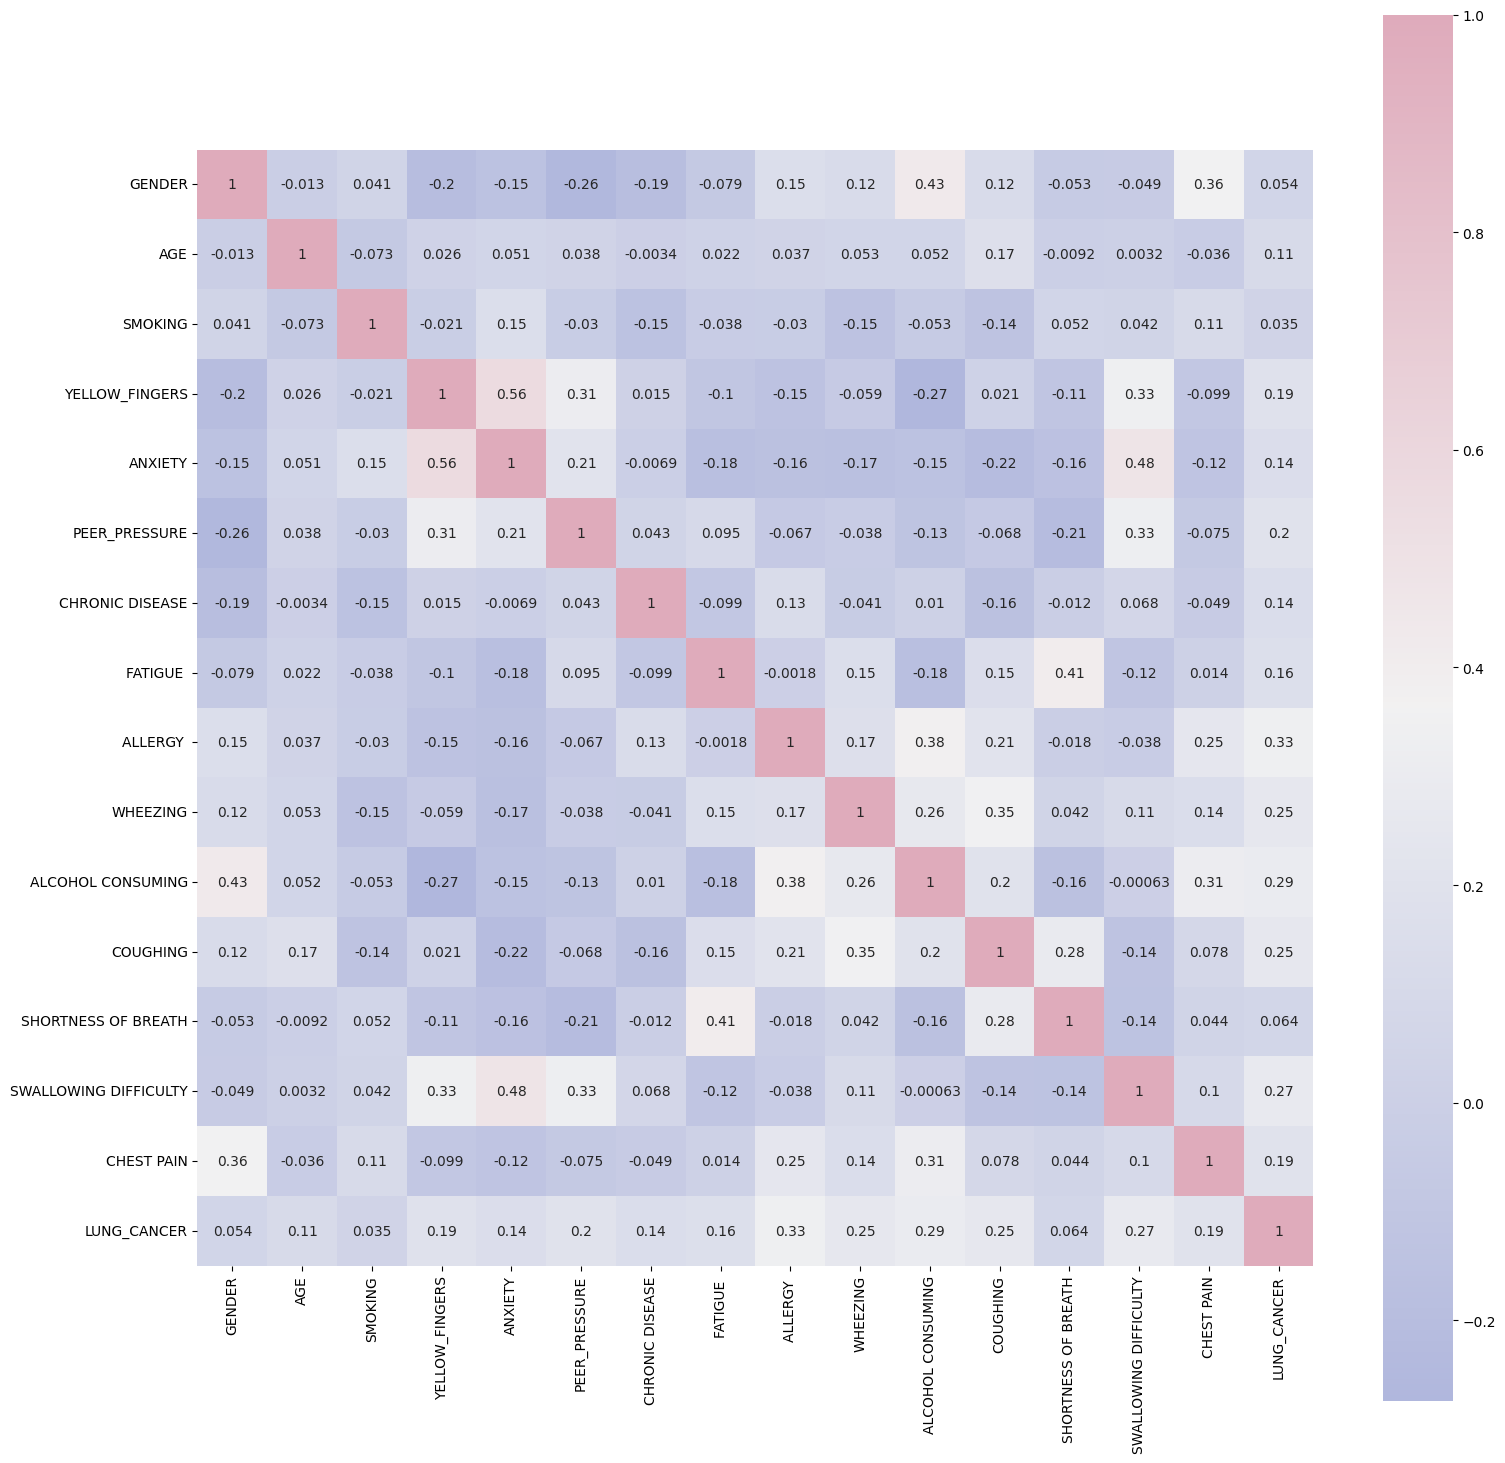

In [35]:
#Şimdi Korelasyonu 'Heatmap' ısı haritası olarak çizdirelim.
 # (Heatmap ile değişkenlerin birbirine korele olup olmadığına bakıyoruz.)

cmap=sns.diverging_palette(260,-10, s=50, l=75, n=6,
                           as_cmap=True)
plt.subplots(figsize=(18,18))
sns.heatmap(cn, cmap=cmap, annot=True, square=True)
plt.show()

<Axes: >

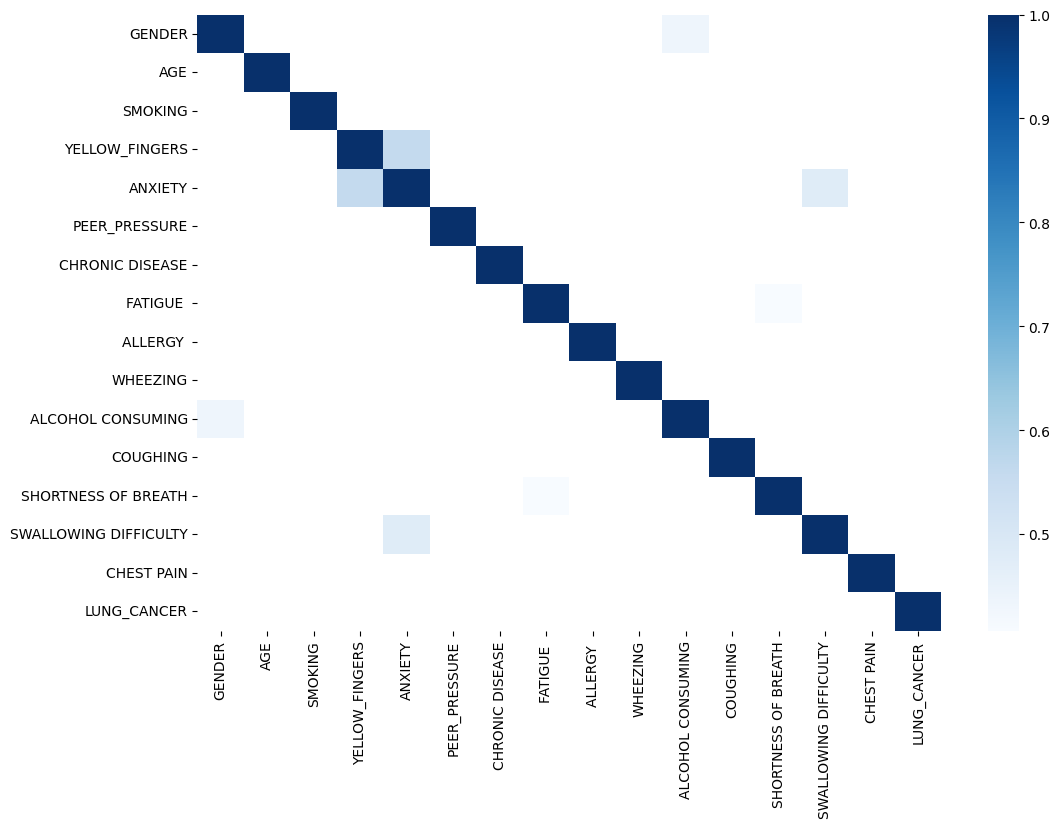

In [41]:
# Korelasyon için değer belirleyip bakma
# Korelasyon 0.40'dan fazla ise korelasyonları göster

kot= cn[cn>.40]
plt.figure(figsize=(12,8))
sns.heatmap(kot, cmap="Blues")

Yukarıdaki yellow fingers ve anxiety arasında önemli bir korelasyon var. Ancak overfit korelasyon var. Burada Naive Based çalışmak overfittingeden dolayı sıkıntı bu yüzden burada 2 farklı yöntem ile sorunu çözebiliriz.

1- Birbiriyle korelasyonları çok yüksek ise birini atabiliriz.

2- Feature Engineering stratejileri uygulayabiliriz.Yani birbiri ile aynı 2 özniteliği çarparak farklı bir kolon oluşturup, o kolonu kullanabiliriz.

Biz Random Forest Kullanacağız.

In [52]:
# Şimdi Modeli Eğitmek İçin Verimizi Ayırıyoruz:
# Buradaki x = Lung_cancer var mı yok mu değişkeni dışındaki herşey - Veriden son kolonu çıkardık.
# y= hedef
X= df.drop('LUNG_CANCER', axis=1)
y= df['LUNG_CANCER']

**Target Distribution Imbalance Handling**

In [53]:
#Elimizdeki ADASYN ile veriyi sentetik veri üreterek arttırıyoruz.

from imblearn.over_sampling import ADASYN
adaysn =ADASYN(random_state=42)  #Adaptive Synthetic Oversampling
X, y = adaysn.fit_resample(X,y)

In [55]:
#Sentetik veri ile şimdi toplam kaç satırımız oldu kontrol edelim

len(X)

483

In [57]:
#Şimdi hasta olup olmamam verisine (hedef) bakalım:
#Aşağıdaki veriye göre sentetik veri ile birlikte, 238 hasta, 245 hasta olmayan kişi var.

from collections import Counter

print(Counter(y))

Counter({0: 245, 1: 238})


**Splitting Data for Training and Test**

Şimdi elimizdeki verinin bir kısmını modeli eğitmek ve diğer kısmını modeli test etmek için ayıracağız. Bunu train_test ile yapacağız.

Makineyi test edeceğimiz etiketli verinin bir kısmını ayırdık. Bu kısmı modeli eğitirken kesinlikle kullanmamalıyız.

In [58]:
# Verinin bir kısmını ayırma:

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.25, random_state=0)

**Naive Bayes**

In [59]:
# Önce Naive Bayes'i çağırarak ilk aşama Naive Bayes kullanalım ve modeli eğitelim
# Fitting multinominal naive bayes classifier to training set
# Burada eğittiğimiz model : mnb_model

from sklearn.naive_bayes import MultinomialNB
mnb_model= MultinomialNB()
mnb_model.fit(X_train, y_train)

MultinomialNB()

In [60]:
#Predicting result using testing data
# Eğittiğimiz model üzerinde predict komutunu kullanarak test verisetimizdeki etiketleri tahmin edelim.
# Verileri tahmin etti 1.veri hasta vs ama tahmin gerçek değil.
y_mnb_pred= mnb_model.predict(X_test)
y_mnb_pred

array([1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1,
       1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0,
       1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0])

In [61]:
# Şimdi ise bir 'Confusion Metrik' oluşturarak gerçek değerler ile tahmin verilerini birbiri ile kıyaslayalım:

from sklearn.metrics import confusion_matrix
cm_mnb= confusion_matrix(y_test, y_mnb_pred)
cm_mnb

array([[56,  4],
       [ 1, 60]])

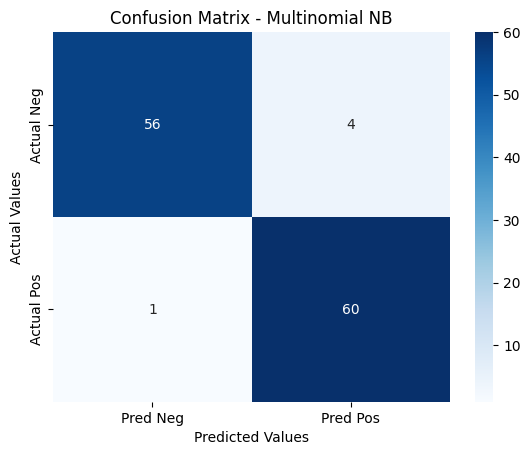

In [62]:
# Şimdi bu karşılaştırma verilerini görselleştirelim:

import seaborn as sns
import matplotlib.pyplot as plt


sns.heatmap(cm_mnb, annot=True, fmt="d", cmap= "Blues",
            xticklabels=["Pred Neg", "Pred Pos"],
            yticklabels=["Actual Neg", "Actual Pos"])

plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.title("Confusion Matrix - Multinomial NB")
plt.show()

In [63]:
# Model Accuracy
# Naive Bayes'e göre göre model %96 accurate çıktı.

from sklearn.metrics import classification_report, accuracy_score, f1_score

mnb_cr= classification_report(y_test, y_mnb_pred)
print(mnb_cr)

              precision    recall  f1-score   support

           0       0.98      0.93      0.96        60
           1       0.94      0.98      0.96        61

    accuracy                           0.96       121
   macro avg       0.96      0.96      0.96       121
weighted avg       0.96      0.96      0.96       121



**Random Forest**

In [64]:
#Şimdi aynı işlemleri bu sefer Random Forest ile yapalım:
# Training
# Burada eğittiğimiz model = rf_model

from sklearn.ensemble import RandomForestClassifier
rf_model= RandomForestClassifier()
rf_model.fit(X_train, y_train)

RandomForestClassifier()

In [65]:
#Şimdi predict ile modeli tahmin ettiriyoruz:

y_rf_pred = rf_model.predict(X_test)
y_rf_pred

array([1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1,
       1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0,
       1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0])

In [67]:
# Şimdi ise bir 'Confusion Metrik' oluşturarak gerçek değerler ile tahmin verilerini birbiri ile kıyaslayalım:

cm_rf= confusion_matrix(y_test, y_rf_pred)

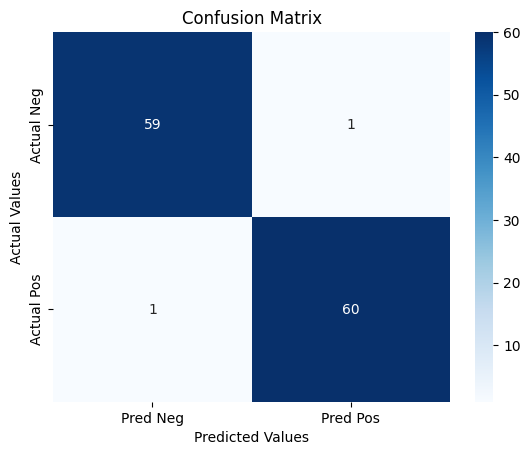

In [71]:
# Şimdi bu karşılaştırma verilerini görselleştirelim:

import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred Neg", "Pred Pos"],
            yticklabels=["Actual Neg", "Actual Pos"])

plt.title("Confusion Matrix")
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.show()

In [72]:
# Ve Random Forest ile yaptığımız işlemde model performansını ölçelim:
# Model Accuracy
# Model %97 accurate çıktı.
rf_cr= classification_report(y_test, y_rf_pred)
print(rf_cr)

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        60
           1       0.98      0.98      0.98        61

    accuracy                           0.98       121
   macro avg       0.98      0.98      0.98       121
weighted avg       0.98      0.98      0.98       121

